In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import yaml

import sys, os
# This is not super pretty, but I think this is the best way to import stuff from ../../../util?
CODE_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if CODE_ROOT not in sys.path:
    sys.path.insert(1, CODE_ROOT)

from inference import initialize_trafo_from_saved_state, get_spectra_reference_point
from train_model import eval_model, collect_dataloaders
from plotting_functions import *

In [3]:
model_name = "realistic_noise_model_snr10"

weights_path = f"../model_states/{model_name}_weights.pt"
config_path = f"../log_files/{model_name}_config.yaml"
plots_save_base_path = "../plots/"

with open(config_path) as f:
    params = yaml.safe_load(f)

suite_of_spectra = params['suite_of_spectra']

In [4]:
train_loader, eval_loader, test_loader, y_mean, y_std = collect_dataloaders(config_path)

In [5]:
len_in = test_loader.dataset.X.shape[1]
len_out = test_loader.dataset.y.shape[1]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, criterion, optimizer = initialize_trafo_from_saved_state(config_path, len_in, len_out, weights_path, device)

In [6]:
# note: this takes about 7 minutes on cpu
_, y_test_true, y_test_pred = eval_model(model, test_loader, criterion, device, return_predictions=True)
y_test_true, y_test_pred  = y_test_true*y_std + y_mean, y_test_pred*y_std + y_mean
y_true, y_pred = y_test_true.numpy(), y_test_pred.numpy()

/vera/u/jerbo/CLIMB-Project/env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [110]:
def plot_test(y_true, y_pred, save_path, save_plot=False):
    from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
    import matplotlib.ticker as mticker

    # --- tweak this one value ---
    # res_fraction = share of the square panel given to the residual plot.
    # e.g. 1/3 → main is 2/3 of the square, residual is 1/3 (and shows 1/3 of the y range)
    #      1/2 → main and residual each take half the square
    res_fraction = 1 / 3.1

    params = [r"$\Omega_m$", r"$\Omega_b$", r"$\Omega_\Lambda$", r"$h$"]
    y_true_by_param = [y_true[:, i] for i in range(len(params))]
    y_pred_by_param = [y_pred[:, i] for i in range(len(params))]

    fig = plt.figure(figsize=(8, 8))
    # hspace/wspace start near-zero; tight_layout will expand only as much as
    # labels require, giving the tightest layout without overlaps
    outer_gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

    for index in range(4):
        col = index // 2
        row = index % 2

        inner_gs = GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer_gs[row, col],
            height_ratios=[1 - res_fraction, res_fraction], hspace=0
        )
        ax_main = fig.add_subplot(inner_gs[0])
        ax_res  = fig.add_subplot(inner_gs[1], sharex=ax_main)

        # main + residual together form a square:
        #   main height  = width * (1 - res_fraction)
        #   res  height  = width *      res_fraction
        ax_main.set_box_aspect(1 - res_fraction)
        ax_res.set_box_aspect(res_fraction)

        y_true_par = y_true_by_param[index]
        y_pred_par = y_pred_by_param[index]
        residuals  = y_pred_par - y_true_par

        y_pred_mean_par, y_pred_std_par = [], []
        y_res_mean_par,  y_res_std_par  = [], []
        y_true_unique_par = []

        for true_value in sorted(set(y_true_par)):
            mask = y_true_par == true_value
            y_pred_mean_par.append(y_pred_par[mask].mean())
            y_pred_std_par.append(y_pred_par[mask].std())
            y_res_mean_par.append(residuals[mask].mean())
            y_res_std_par.append(residuals[mask].std())
            y_true_unique_par.append(true_value)

        y_pred_mean_par = np.array(y_pred_mean_par)
        y_pred_std_par  = np.array(y_pred_std_par)
        y_res_mean_par  = np.array(y_res_mean_par)
        y_res_std_par   = np.array(y_res_std_par)

        # --- main plot ---
        line_vals = sorted(y_true_par)
        ax_main.plot(line_vals, line_vals, linestyle="--", c="red", alpha=0.7, zorder=2)
        ax_main.errorbar(y_true_unique_par, y_pred_mean_par, yerr=y_pred_std_par,
                         linestyle="None", marker="x", color="black", zorder=3,
                         label=r"mean with 1$\sigma$ std")
        ax_main.set_ylabel(r"predicted")
        ax_main.set_title(params[index])
        ax_main.tick_params(labelbottom=False, bottom=True)

        # --- residual plot ---
        ax_res.axhline(0, linestyle="--", c="red", alpha=0.7, zorder=2)
        ax_res.errorbar(y_true_unique_par, y_res_mean_par, yerr=y_res_std_par,
                        linestyle="None", marker="x", color="black", zorder=3)
        ax_res.set_xlabel(r"true")
        ax_res.set_ylabel(r"residual")
        ax_res.tick_params(top=True, labeltop=False)

        # --- matched y scales ---
        y_lo = min(y_pred_par.min(), (y_pred_mean_par - y_pred_std_par).min())
        y_hi = max(y_pred_par.max(), (y_pred_mean_par + y_pred_std_par).max())
        pad  = (y_hi - y_lo) * 0.05
        y_lo -= pad;  y_hi += pad
        main_span = y_hi - y_lo
        ax_main.set_ylim(y_lo, y_hi)

        res_center = float(np.mean(y_res_mean_par))
        ax_res.set_ylim(res_center - main_span * res_fraction / 2,
                        res_center + main_span * res_fraction / 2)

        # same tick spacing on both axes
        raw_step  = main_span / 5
        magnitude = 10 ** np.floor(np.log10(raw_step))
        norm      = raw_step / magnitude
        if norm < 1.5:
            step = magnitude
        elif norm < 3.5:
            step = 2 * magnitude
        elif norm < 7.5:
            step = 5 * magnitude
        else:
            step = 10 * magnitude
        ax_main.yaxis.set_major_locator(mticker.MultipleLocator(step))
        ax_res.yaxis.set_major_locator(mticker.MaxNLocator(nbins=1))

    plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.3)
    if save_plot:
        plt.savefig(save_path, format="PDF", bbox_inches="tight")
    plt.show()

/tmp/ipykernel_33216/3161331299.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.3)


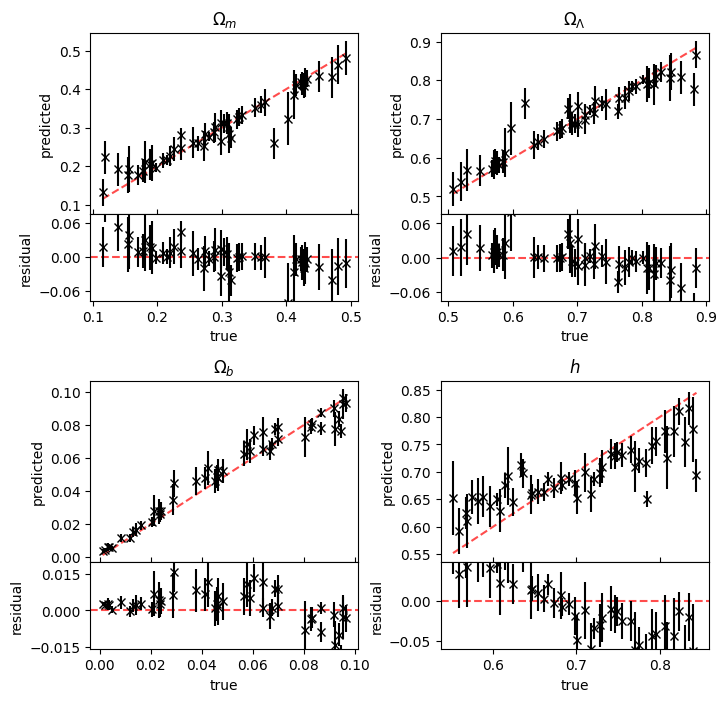

In [112]:
save_path = plots_save_base_path + f"{model_name}_errorbars_and_residuals.pdf"
plot_test(y_true, y_pred, save_path=save_path, save_plot=True)

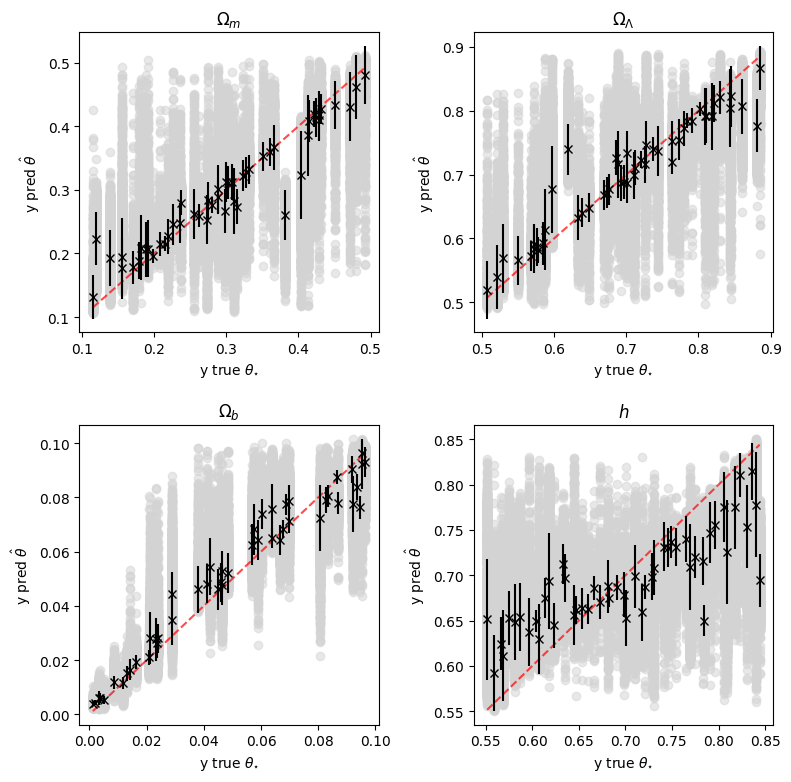

In [22]:
save_path = plots_save_base_path + f"{model_name}_errorbars.pdf"
plot_test_inference_errorbars(y_true, y_pred, save_path, save_plot=True)

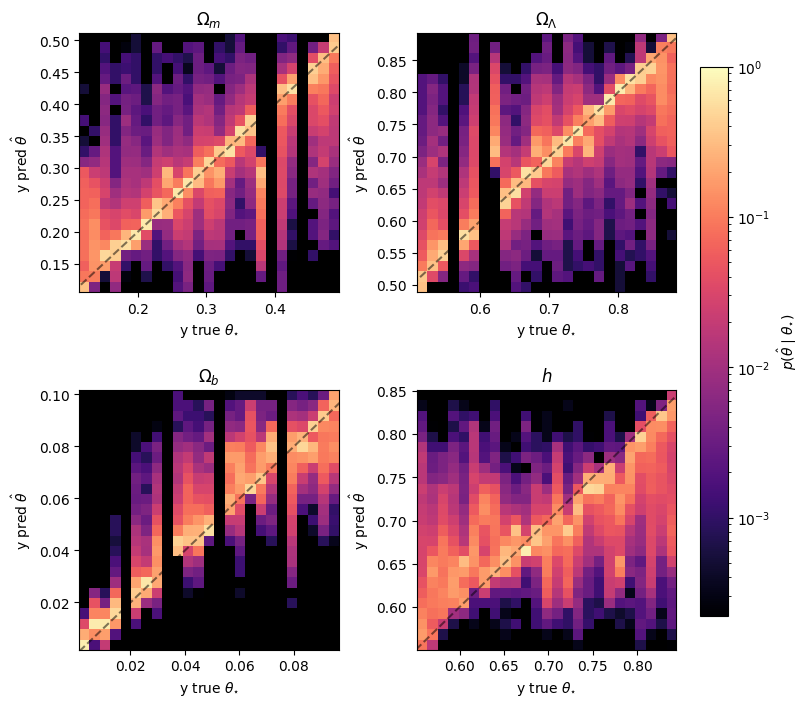

In [23]:
def plot_test_inference_colors(y_true, y_pred, save_path, save_plot=False):
    params = [r"$\Omega_m$", r"$\Omega_b$", r"$\Omega_\Lambda$", r"$h$"]

    y_true_by_param = [y_true[:, i] for i in range(len(params))]
    y_pred_by_param = [y_pred[:, i] for i in range(len(params))]

    fig, axs = plt.subplots(2, 2, figsize=(8, 7.15), constrained_layout=True)

    for index in range(4):

        y_true_par = y_true_by_param[index]
        y_pred_par = y_pred_by_param[index]

        # ---------- mean and std per true value ----------
        y_pred_mean_par = []
        y_pred_std_par = []
        y_true_unique_par = []

        for true_value in np.unique(y_true_par):
            y_pred_this_true_value = y_pred_par[y_true_par == true_value]
            y_pred_mean_par.append(y_pred_this_true_value.mean())
            y_pred_std_par.append(y_pred_this_true_value.std())
            y_true_unique_par.append(true_value)

        # ---------- equally spaced bins ----------
        n_bins =  25 # len(np.unique(y_true_par))

        x_min, x_max = y_true_par.min(), y_true_par.max()
        y_min, y_max = y_pred_par.min(), y_pred_par.max()

        x_edges = np.linspace(x_min, x_max, n_bins + 1)
        y_edges = np.linspace(y_min, y_max, n_bins + 1)

        # ---------- 2D histogram ----------
        H, _, _ = np.histogram2d(
            y_true_par,
            y_pred_par,
            bins=[x_edges, y_edges]
        )

        # sum over y for each x-bin
        col_sums = H.sum(axis=1, keepdims=True)

        # avoid division by zero for empty columns
        H_norm = np.divide(
            H,
            col_sums,
            out=np.zeros_like(H),
            where=col_sums > 0
        )

        H_norm[H_norm == 0] = np.nan

        ax = axs[index % 2, index // 2]

        ax.set_box_aspect(1)
        ax.set_facecolor("black")

        # ---------- density image ----------
        im = ax.imshow(
            H_norm.T,
            origin="lower",
            extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
            cmap="magma",
            norm=LogNorm(vmin=np.nanmin(H_norm), vmax=1.0),
            aspect="auto",
            zorder=1
        )

        # ---------- y = x line ----------
        line_min = min(x_min, y_min)
        line_max = max(x_max, y_max)

        ax.plot(
            [line_min, line_max],
            [line_min, line_max],
            linestyle="--",
            c="black",
            alpha=0.5,
            zorder=3
        )

        ax.set_xlim([x_min, x_max])
        ax.set_ylim([y_min, y_max])
        ax.set_title(params[index])

        ax.set_xlabel(r"y true $\theta_{\star}$")
        ax.set_ylabel(r"y pred $\hat{\theta}$")

    # ---------- colorbar ----------
    cbar = fig.colorbar(im, ax=axs, fraction=0.046, pad=0.04)
    cbar.set_label(r"$p(\hat{\theta} \mid \theta_{\star})$")

    if save_plot:
        plt.savefig(save_path, format="PDF")
    plt.show()

save_path = plots_save_base_path + f"{model_name}_colors.pdf"
plot_test_inference_colors(y_true, y_pred, save_path, save_plot=True)

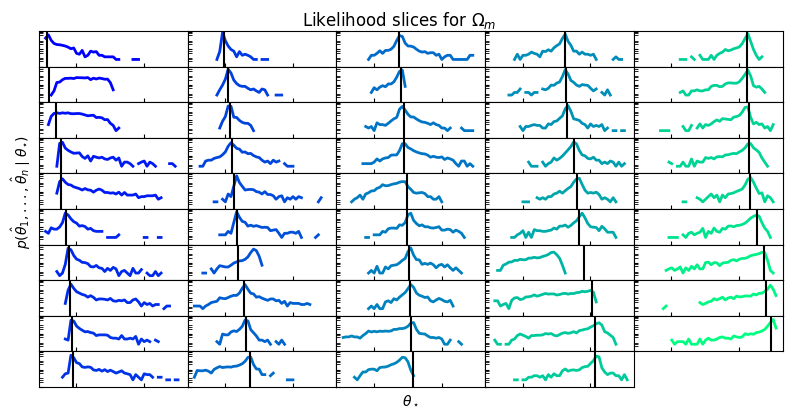

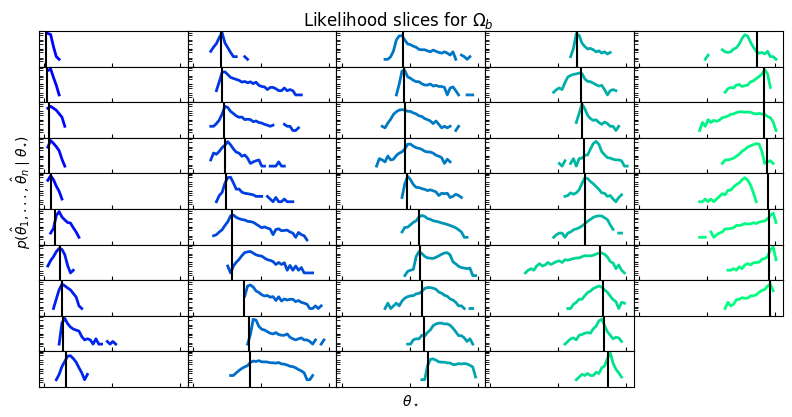

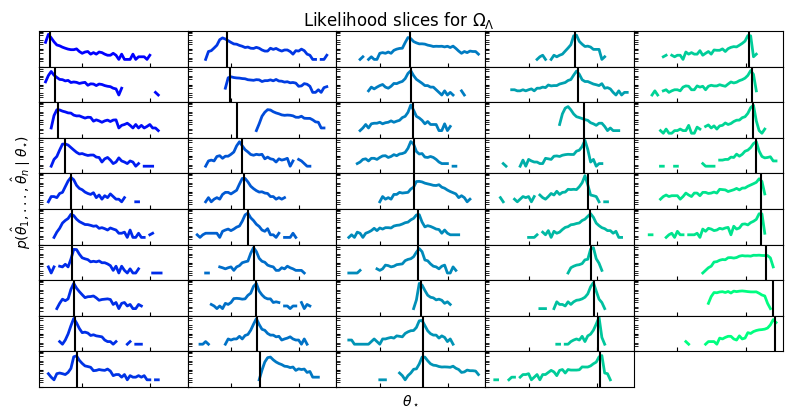

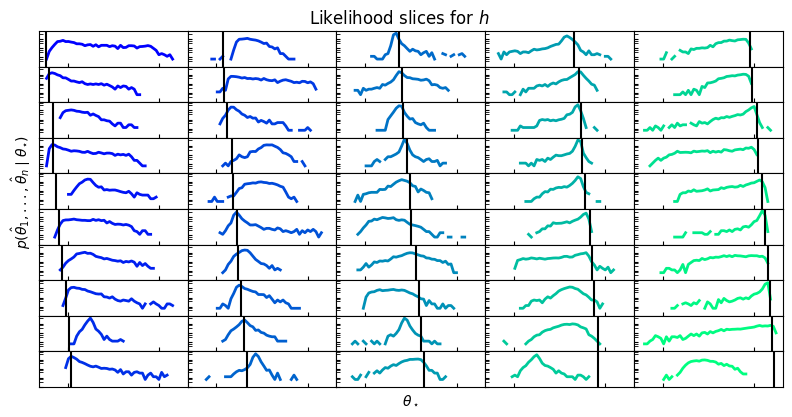

In [24]:
save_path = "/vera/u/jerbo/CLIMB-Project/code/Machine_Learning/Transformer_pipeline/plots/" + f"{model_name}_PDF.pdf"
plot_all_PDFs(y_true, y_pred, save_path, save_plot=True)

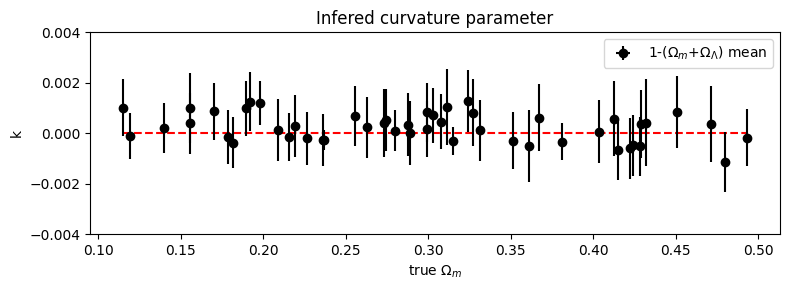

In [25]:
save_path = plots_save_base_path + f"{model_name}_curvature.pdf"
plot_curvature_param(y_true, y_pred, save_path, save_plot=True)

In [26]:
def predict_loader(model, X, device, batch_size=128):
    loader = DataLoader(TensorDataset(X), batch_size=batch_size)
    preds = []

    model.eval()
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            preds.append(model(xb).cpu())

    return torch.cat(preds)

In [27]:
ref_box_specs, _ = get_spectra_reference_point(suite_of_spectra, n_spectra=10000)
ref_box_specs = torch.Tensor(ref_box_specs)

In [28]:
# note: this takes about a minute on cpu
y_pred_ref = predict_loader(model, ref_box_specs, device)

y_pred_ref = y_pred_ref*y_std + y_mean
y_pred_ref = y_pred_ref.numpy()

In [29]:
# make_corner_plot(y_pred_ref, "ref_corner_path", False)

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D


def _kde_2d(x, y, gridsize=200, bw_scale=0.5, bounds=None):
    values = np.vstack([x, y])
    kde = gaussian_kde(values)
    kde.covariance_factor = lambda: kde.scotts_factor() * bw_scale
    kde._compute_covariance()

    if bounds is None:
        xmin, xmax = x.min(), x.max()
        ymin, ymax = y.min(), y.max()
    else:
        xmin, xmax, ymin, ymax = bounds

    xx, yy = np.meshgrid(
        np.linspace(xmin, xmax, gridsize),
        np.linspace(ymin, ymax, gridsize)
    )
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    return xx, yy, zz


def _credible_threshold(density, level=0.68):
    z = density.ravel()
    idx = np.argsort(z)[::-1]
    z_sorted = z[idx]
    cdf = np.cumsum(z_sorted)
    cdf /= cdf[-1]
    return z_sorted[np.searchsorted(cdf, level)]


def make_corner_plot_custom(
    y_preds,
    labels,
    model_names=None,
    axis_limits=None,
    planck=None,
    planck_err=None,
    planck_color="#333333",
    bw_scale=0.4,
    fill_alpha=0.5,
    gridsize=180,
    bins=50,
    show_2sigma=False,
    figsize=(8, 8),
    fill_colors=None,
    edge_colors=None,
    save_path=None,
    show_plot=True
):

    n_dim = y_preds[0].shape[1]

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(n_dim, n_dim, figure=fig, wspace=0.0, hspace=0.0)

    axes = np.empty((n_dim, n_dim), dtype=object)

    for i in range(n_dim):
        for j in range(n_dim):

            if i < j:
                axes[i, j] = None
                continue

            sharex = axes[n_dim - 1, j] if i < n_dim - 1 else None
            sharey = axes[i, 0] if (i != j and j > 0) else None

            axes[i, j] = fig.add_subplot(gs[i, j], sharex=sharex, sharey=sharey)
    if fill_colors is None:
        fill_colors = ["#63a5d4", "#de7171", "#6fd66f", "#cfa2f8", "#ffa556"]
    if edge_colors is None: 
        edge_colors = ["#176395", "#a90c0c", "#199b3c", "#4b0082", "#8c3f00"]

    for i in range(n_dim):
        for j in range(n_dim):

            ax = axes[i, j]
            if ax is None:
                continue

            for k, samples in enumerate(y_preds):

                color = fill_colors[k % len(fill_colors)]
                edge = edge_colors[k % len(edge_colors)]

                if i == j:

                    data = samples[:, i]

                    if axis_limits and axis_limits[i] is not None:
                        xmin, xmax = axis_limits[i]
                        data = data[(data >= xmin) & (data <= xmax)]
                        hist_range = (xmin, xmax)
                    else:
                        hist_range = None

                    ax.hist(
                        data,
                        bins=bins,
                        range=hist_range,
                        density=True,
                        histtype="step",
                        linewidth=1.4,
                        color=color
                    )

                    if planck is not None:
                        ax.axvline(planck[i], color=planck_color, lw=1.0, linestyle="--", zorder=5)
                        ax.axvspan(
                            planck[i] - planck_err[i],
                            planck[i] + planck_err[i],
                            color=planck_color,
                            alpha=0.2,
                            zorder=5
                        )

                    ax.tick_params(labelleft=False)

                else:

                    x = samples[:, j]
                    y = samples[:, i]

                    bounds = None
                    if axis_limits and axis_limits[i] is not None:
                        xmin, xmax = axis_limits[j]
                        ymin, ymax = axis_limits[i]
                        bounds = (xmin, xmax, ymin, ymax)

                    xx, yy, zz = _kde_2d(x, y, gridsize, bw_scale, bounds)

                    thr_1 = _credible_threshold(zz, 0.68)

                    if show_2sigma:
                        thr_2 = _credible_threshold(zz, 0.95)

                        ax.contourf(
                            xx, yy, zz,
                            levels=[thr_2, zz.max()],
                            colors=[color],
                            alpha=fill_alpha * 0.5
                        )

                    ax.contourf(
                        xx, yy, zz,
                        levels=[thr_1, zz.max()],
                        colors=[color],
                        alpha=fill_alpha
                    )

                    ax.contour(
                        xx, yy, zz,
                        levels=[thr_1],
                        colors=[edge],
                        linewidths=1.5,
                    )

                    if show_2sigma:
                        ax.contour(
                            xx, yy, zz,
                            levels=[thr_2],
                            colors=[edge],
                            linewidths=1.0,
                            # linestyles="dashed"
                        )

                    if planck is not None:
                        ax.axvline(planck[j], color=planck_color, lw=1.0, linestyle="--")
                        ax.axhline(planck[i], color=planck_color, lw=1.0, linestyle="--")

            if axis_limits:
                if i == j:
                    ax.set_xlim(axis_limits[i])
                else:
                    ax.set_xlim(axis_limits[j])
                    ax.set_ylim(axis_limits[i])

            ax.tick_params(direction="in", top=True, right=True)

            if j == 0 and i != j:
                ax.tick_params(labelleft=True)
                ax.set_ylabel(labels[i])
            elif j != 0:
                ax.tick_params(labelleft=False)

            if i == n_dim - 1:
                ax.set_xlabel(labels[j])
            else:
                ax.tick_params(labelbottom=False)

    if model_names is not None:

        legend_elements = [
            Patch(
                facecolor=fill_colors[i],
                edgecolor=edge_colors[i],
                label=model_names[i],
                alpha=fill_alpha
            )
            for i in range(len(model_names))
        ]

        legend_elements.append(
            Line2D(
                [0], [0],
                color="black",
                linestyle="--",
                linewidth=1.3,
                label="Planck 2015"
            )
        )

        anchor_x = (n_dim - 0.5) / n_dim
        anchor_y = (n_dim - 0.5) / n_dim

        fig.legend(
            handles=legend_elements,
            loc="center",
            bbox_to_anchor=(anchor_x, anchor_y),
            frameon=False
        )

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    if show_plot:
        plt.show()

    plt.close()

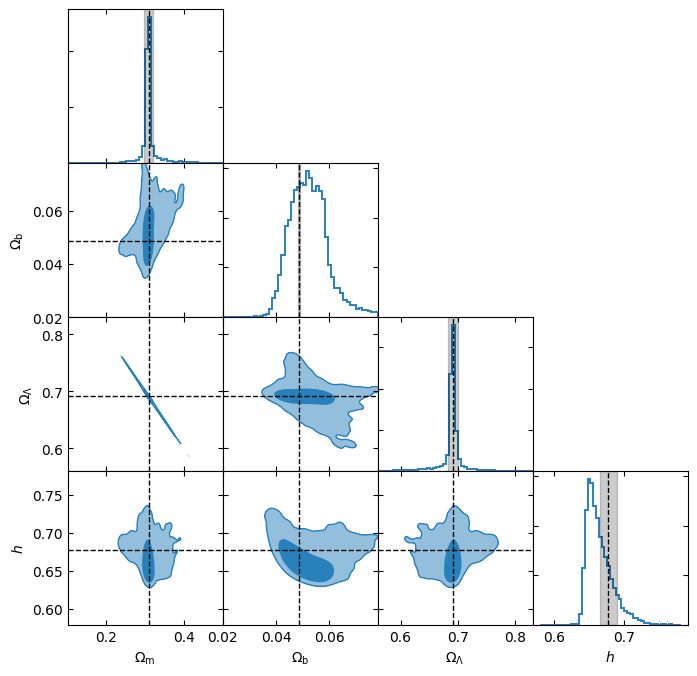

In [34]:
save_path = plots_save_base_path + f"{model_name}_refbox_cornerplot.pdf"

axis_limits = [
        (0.1, 0.5),
        (0.02, 0.078),
        (0.56, 0.83),
        None
    ]

colors = ["#2981BB", "#a90c0c", "#199b3c", "#4b0082", "#8c3f00"]

make_corner_plot_custom(
    [y_pred_ref],

    labels=[
        r"$\Omega_{\mathrm{m}}$",
        r"$\Omega_{\mathrm{b}}$",
        r"$\Omega_{\Lambda}$",
        r"$h$"
    ],

    # model_names=["Teset"],

    axis_limits=axis_limits,

    planck=np.array([0.3089, 0.0486, 0.6911, 0.6774]),
    planck_err=np.array([0.012, 2.2e-4, 0.009, 0.012]),

    bw_scale=1,   # lower = sharper contours
    fill_alpha=1,
    gridsize=250,
    bins=50,
    figsize=(8,8),
    planck_color="#000000",
    fill_colors=colors,
    edge_colors=colors,
    show_2sigma=True,

    save_path=save_path
)

In [32]:
print(f"{np.mean(np.array(y_pred_ref), axis=0)}")
print(f"{np.std(np.array(y_pred_ref), axis=0)}")

[0.31128848 0.05270914 0.68821096 0.6649026 ]
[0.02312433 0.00777692 0.02318492 0.01981744]
